In [ ]:
import pandas as pd

df = pd.read_csv('/content/ncr_ride_bookings.csv')
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [ ]:
df.shape
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

,0
Date,0
Time,0
Booking ID,0
Booking Status,0
Customer ID,0
Vehicle Type,0
Pickup Location,0
Drop Location,0
Avg VTAT,10500
Avg CTAT,48000


In [ ]:
df.drop_duplicates(inplace=True)

df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df['Hour'] = df['Date'].dt.hour
df['Day'] = df['Date'].dt.day_name()

In [ ]:
total_bookings = len(df)
total_revenue = df['Booking Value'].sum()

cancel_rate = (df['Booking Status'] == 'Cancelled').mean() * 100

In [ ]:
df.groupby('Hour').size()
df.groupby('Day').size()

,0
Day,
Friday,21397
Monday,21644
Saturday,21542
Sunday,21398
Thursday,21215
Tuesday,21391
Wednesday,21413


In [ ]:
df.to_csv('cleaned_uber_data.csv', index=False)

In [ ]:
df['Booking Value'].fillna(df['Booking Value'].mean(), inplace=True)
df['Ride Distance'].fillna(df['Ride Distance'].mean(), inplace=True)
df['Driver Ratings'].fillna(df['Driver Ratings'].mean(), inplace=True)
df['Customer Rating'].fillna(df['Customer Rating'].mean(), inplace=True)

/tmp/ipykernel_4794/4120370488.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Booking Value'].fillna(df['Booking Value'].mean(), inplace=True)
/tmp/ipykernel_4794/4120370488.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, 

In [ ]:
df['Payment Method'].fillna('Unknown', inplace=True)
df['Vehicle Type'].fillna('Unknown', inplace=True)
df['Booking Status'].fillna('Unknown', inplace=True)

/tmp/ipykernel_4794/1950600742.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Payment Method'].fillna('Unknown', inplace=True)
/tmp/ipykernel_4794/1950600742.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [ ]:
df.drop([
    'Cancelled Rides by Customer',
    'Reason for cancelling by Customer',
    'Cancelled Rides by Driver',
    'Driver Cancellation Reason',
    'Incomplete Rides',
    'Incomplete Rides Reason'
], axis=1, inplace=True)

In [ ]:
df['Month'] = df['Date'].dt.month
df['Weekend'] = df['Day'].isin(['Saturday','Sunday'])

In [ ]:
total_bookings = len(df)
total_revenue = df['Booking Value'].sum()
avg_fare = df['Booking Value'].mean()

completed = (df['Booking Status'] == 'Completed').sum()
cancelled = (df['Booking Status'] == 'Cancelled').sum()

completion_rate = (completed / total_bookings) * 100
cancel_rate = (cancelled / total_bookings) * 100

In [ ]:
df.groupby('Hour').size().sort_values(ascending=False)

,0
Hour,
0,150000


In [ ]:
df['Pickup Location'].value_counts().head(10)

,count
Pickup Location,
Khandsa,949
Barakhamba Road,946
Saket,931
Badarpur,921
Pragati Maidan,920
Madipur,919
AIIMS,918
Mehrauli,915
Dwarka Sector 21,914


In [ ]:
df.groupby('Vehicle Type')['Booking Value'].sum()

,Booking Value
Vehicle Type,
Auto,1.898001e+07
Bike,1.147455e+07
Go Mini,1.513783e+07
Go Sedan,1.385441e+07
Premier Sedan,9.221415e+06
Uber XL,2.241679e+06
eBike,5.334492e+06


In [ ]:
df[df['Booking Status']=='Cancelled']['Vehicle Type'].value_counts()

,count
Vehicle Type,


In [ ]:
df['Payment Method'].value_counts()

,count
Payment Method,
Unknown,48000
UPI,45909
Cash,25367
Uber Wallet,12276
Credit Card,10209
Debit Card,8239


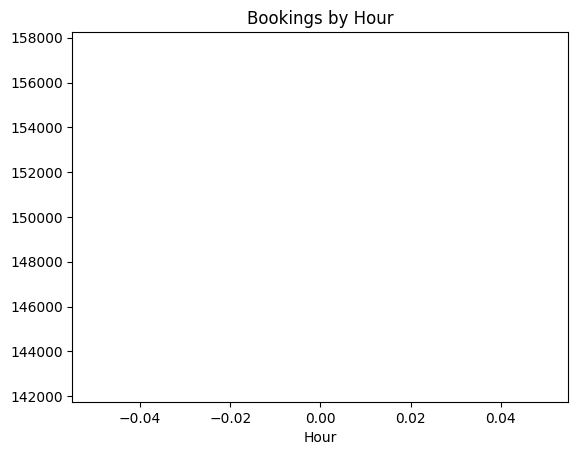

In [ ]:
import matplotlib.pyplot as plt

df.groupby('Hour').size().plot(kind='line')
plt.title('Bookings by Hour')
plt.show()

In [ ]:
df.to_csv('final_cleaned_uber_data.csv', index=False)

In [ ]:
df['Datetime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'])

In [ ]:
df['Hour'] = df['Datetime'].dt.hour

In [ ]:
df['Hour'].value_counts().sort_index()

,count
Hour,
0,1373
1,1360
2,1339
3,1383
4,1321
5,2786
6,4160
7,5450
8,6861


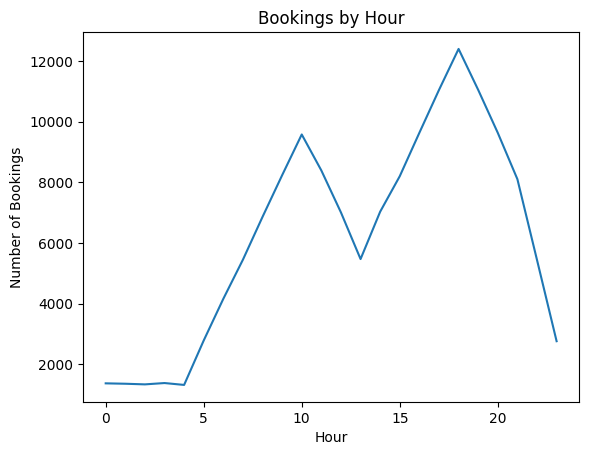

In [ ]:
import matplotlib.pyplot as plt

df.groupby('Hour').size().plot(kind='line')
plt.title('Bookings by Hour')
plt.xlabel('Hour')
plt.ylabel('Number of Bookings')
plt.show()

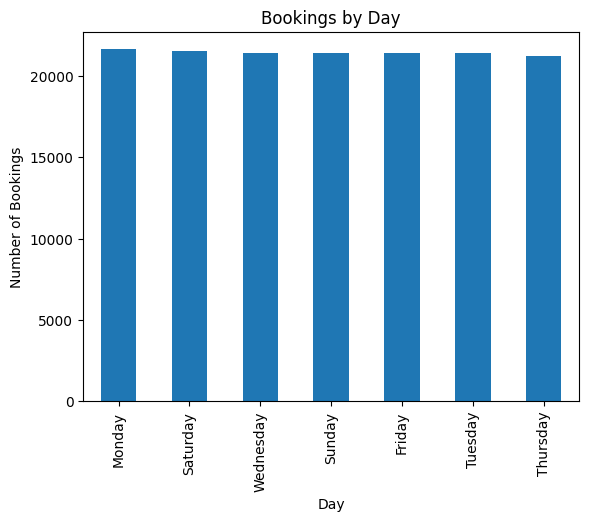

In [ ]:
df['Day'] = df['Datetime'].dt.day_name()

df['Day'].value_counts().plot(kind='bar')
plt.title('Bookings by Day')
plt.xlabel('Day')
plt.ylabel('Number of Bookings')
plt.show()

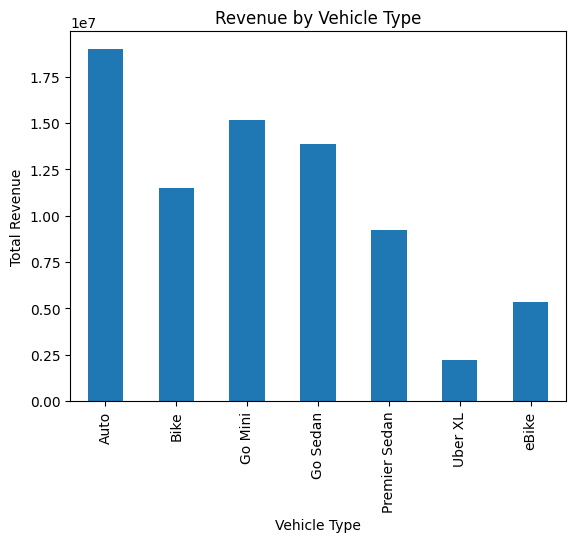

In [ ]:
df.groupby('Vehicle Type')['Booking Value'].sum().plot(kind='bar')
plt.title('Revenue by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Total Revenue')
plt.show()

In [48]:
df.to_csv('final_cleaned_uber_data.csv', index=False)